<a href="https://colab.research.google.com/github/AdhikariSara/AdvancedSQL_Sara/blob/main/L03_Grid_Approx_f24_ipynb_adhikari%2CPulidoC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [L03: Grid Approximation TSP](https://docs.google.com/document/d/1PIzgQa9iLFFrNkSYzNr6Bj-NtsB-UywrwfYtk5HSfv4)
Written by Dr. Jan Pearce, Berea College

Complete the code by meeting all linked requirements and fixing all FIXMEs

## Your Name: Sara Adhikari, Claudia Pulido

**SUMMARY**: We started by understanding the Recursive Grid Approximation algorithm and its requirements for solving the Traveling Salesman Problem (TSP). Initially, we planned to divide the cities into grids and solve each small grid individually, then connect the smaller tours. The design evolved as we tested different ways to combine the tours, trying to find the shortest path. Overall, we successfully implemented the grid-based partitioning and the recursive process. It took us about 20 hours to complete, working mostly together as a team.

**PERSONNEL**: Sara Adhikari and Claudia Pulido worked together as pair programmers on this lab. We both collaborated on the grid splitting, combining subtours, and testing different input files. Throughout the code, we included comments to clarify who worked on which section.

**CHALLENGES**: The biggest challenge was figuring out how to connect subtours effectively. We had to ensure that combining the tours always resulted in a shorter overall path. Another challenge was handling edge cases when splitting grids and ensuring that the recursion stops correctly.

**INNOVATIONS**: We added adaptive partitioning, where the grid splits based on the width and height of the current grid area. This made the algorithm more flexible and efficient. We also used caching to speed up the recursive calls.

**TESTING**: We tested the program using different input files, such as tsp-small.txt and randomly generated data. We checked if the final output had the correct number of cities and formed a valid TSP tour. We also used visualization to confirm that the graph matched the expected output.

**ERRORS**:
 1) Sometimes the program would get stuck in an infinite loop if the grid partitioning was not handled correctly.

2) The program struggled with very large inputs, making it slow or causing memory issues.

**COMMENTS**:This lab was a great experience in implementing a complex algorithm like the Recursive Grid Approximation. We learned a lot about recursive techniques and grid-based problem-solving. Working together made it easier to identify and solve problems, and the visualization helped us understand the behavior of the TSP solution better but it did take lot of our time.

Acknowledgement: Used Generative Ai for some help with understanding the lab.



In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math
from urllib.request import urlopen
import random
import itertools

### Read data

In [ ]:
def get_new_node_coords(numnodes, scale=1):
    nodeStr = f'{numnodes}\n'
    coords = []
    for i in range(numnodes):
        x, y = random.randint(1, numnodes//scale), random.randint(1, numnodes//scale)
        while (x, y) in coords:
            x, y = random.randint(1, numnodes//scale), random.randint(1, numnodes//scale)
        coords.append((x, y))
        nodeStr += f'{x} {y}\n'
    return nodeStr


# tspdata = urlopen("http://cs.berea.edu/courses/csc445/data/tsp-48.txt").read().decode('ASCII')
# tspdata = urlopen("http://cs.berea.edu/courses/csc445/data/tsp-small.txt").read().decode('ASCII')
tspdata = get_new_node_coords(20)
print(tspdata)

20
6 1
11 16
6 2
3 9
2 19
10 4
11 10
18 18
5 8
12 6
2 15
19 20
15 18
8 15
4 4
16 5
20 9
13 15
16 13
7 17



## TSP Class

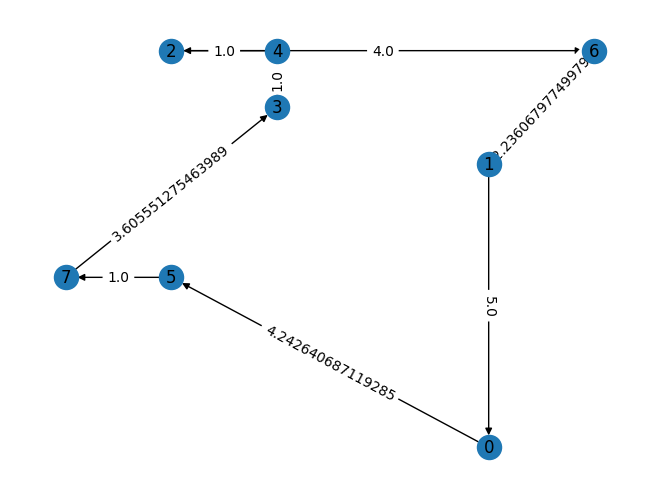

8
3 7
3 8
2 8
6 8
5 6
5 1
2 4
1 4



In [ ]:
MAX_CITIES_PER_GRID = 4  # Maximum number of cities per grid before stopping partitioning

class TSP:
    def __init__(self):
        """ TSP class containing data needed for networkx graph creation, file reading, and file writing.
            Creates a graph for the traveling salesperson problem.
        """
        self.dimension = None
        self.nodeData = []
        self.graph = nx.DiGraph()
        self.coords = {}
        self.route = []

    def extractData(self, inputData):
        """ Iterates through the input data and appends each coordinate into the node list.
        Arguments:
            inputData {str} -- a string containing the number of nodes followed by coordinates
        """
        lines = inputData.strip().split('\n')
        self.dimension = int(lines[0])  # Number of vertices

        for line in lines[1:]:
            nodeX, nodeY = map(int, line.split())
            self.nodeData.append([nodeX, nodeY])

    def setUpCoords(self):
        """ Puts the coordinates for each node into a dictionary as a tuple with the node as the key """
        for i in range(len(self.nodeData)):
            self.coords[i] = self.nodeData[i]

    def calculateDistance(self, a, b):
        """ Calculates & returns the distance between points a and b """
        x1, y1 = float(a[0]), float(a[1])
        x2, y2 = float(b[0]), float(b[1])
        return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    def calculateTotalDistance(self, route=None):
        """Calculates the total distance of the given route, ensuring it returns to the starting point."""
        if route is None:
            route = self.route

        total = 0
        for i in range(len(route) - 1):
            n1 = self.coords[route[i]]
            n2 = self.coords[route[i + 1]]
            total += self.calculateDistance(n1, n2)

        # Add distance from the last node back to the starting node
        total += self.calculateDistance(self.coords[route[-1]], self.coords[route[0]])
        return total

    def verticalPartition(self, nodes, yval):
        """ Splits the list 'nodes' into two lists, top and bottom, based on yval. """
        top, bottom = [], []
        for i in nodes:
            if self.coords[i][1] >= yval:
                top.append(i)
            else:
                bottom.append(i)
        return top, bottom

    def horizontalPartition(self, nodes, xval):
        """ Splits the list 'nodes' into two lists, left and right, based on xval. """
        left, right = [], []
        for i in nodes:
            if self.coords[i][0] <= xval:
                left.append(i)
            else:
                right.append(i)
        return left, right

    def getBounds(self, nodes):
        """ Gets the bounding box containing every node in 'nodes' """
        allcoords = [self.coords[i] for i in nodes]
        myx = [i[0] for i in allcoords]
        myy = [i[1] for i in allcoords]
        return {'xmax': max(myx), 'xmin': min(myx), 'ymax': max(myy), 'ymin': min(myy)}

    def sortClockwise(self, nodes):
        """ Sorts nodes in a clockwise order around their centroid """
        # Calculate centroid of nodes
        centroid_x = sum(self.coords[n][0] for n in nodes) / len(nodes)
        centroid_y = sum(self.coords[n][1] for n in nodes) / len(nodes)
        # Sort nodes by angle relative to centroid
        return sorted(nodes, key=lambda n: math.atan2(self.coords[n][1] - centroid_y, self.coords[n][0] - centroid_x))

    def gridApprox(self, currentNodes=None):
        """ Recursively approximates the TSP tour by partitioning the nodes into grids. """
        if currentNodes is None:
            currentNodes = tuple(range(self.graph.number_of_nodes()))

        if len(currentNodes) <= MAX_CITIES_PER_GRID:  # Base case: small partition
            return self.sortClockwise(list(currentNodes))

        bounds = self.getBounds(currentNodes)
        xmin, xmax = bounds['xmin'], bounds['xmax']
        ymin, ymax = bounds['ymin'], bounds['ymax']

        xval = (xmin + xmax) / 2
        yval = (ymin + ymax) / 2

        width, height = xmax - xmin, ymax - ymin

        if width > height:  # Adaptive horizontal split
            left, right = self.horizontalPartition(currentNodes, xval)
            left_tour = self.gridApprox(tuple(left))
            right_tour = self.gridApprox(tuple(right))
            return self.combineTours(left_tour, right_tour, 'horizontal')
        else:  # Adaptive vertical split
            top, bottom = self.verticalPartition(currentNodes, yval)
            top_tour = self.gridApprox(tuple(top))
            bottom_tour = self.gridApprox(tuple(bottom))
            return self.combineTours(top_tour, bottom_tour, 'vertical')

    def combineTours(self, tour1, tour2, split='horizontal'):
        """Combines two subtours into one, choosing the best combination by distance."""
        if not tour1:
            return tour2
        if not tour2:
            return tour1

        # Only check combinations of edges at the ends of each tour
        candidates = [
            (tour1, tour2),
            (tour1, tour2[::-1]),
            (tour1[::-1], tour2),
            (tour1[::-1], tour2[::-1])
        ]

        best_tour = None
        best_length = float('inf')

        # Evaluate each combination
        for t1, t2 in candidates:
            combined_route = t1 + t2
            total_distance = self.calculateTotalDistance(combined_route)

            if total_distance < best_length:
                best_length = total_distance
                best_tour = combined_route

        return best_tour

    def addNodes(self):
        """ Adds nodes to the networkx graph """
        for node in self.coords:
            self.graph.add_node(node, pos=self.coords[node])

    def addEdges(self, route=None):
        """ Adds edges to a networkx graph, ensuring the last node returns to the first node """
        if route is None:
            route = self.route
        for i in range(len(route) - 1):
            self.graph.add_edge(route[i], route[i + 1], weight=self.calculateDistance(self.coords[route[i]], self.coords[route[i + 1]]))
        # Add the edge connecting the last node to the first to complete the tour
        self.graph.add_edge(route[-1], route[0], weight=self.calculateDistance(self.coords[route[-1]], self.coords[route[0]]))

    def showGraph(self):
        """ Uses the imported libraries to display the graph """
        coords = nx.get_node_attributes(self.graph, 'pos')
        labels = nx.get_edge_attributes(self.graph, 'weight')
        nx.draw(self.graph, coords, with_labels=True)
        nx.draw_networkx_edge_labels(self.graph, coords, edge_labels=labels)
        plt.show()

    def formatOutput(self):
        """ Returns the formatted output of the solution path as a triple-quoted string """
        output = f"{self.dimension}\n"
        for node in self.route:
            x, y = self.coords[node]
            output += f"{x} {y}\n"
        return output

def get_new_node_coords(numnodes, scale=1):
    """Generates random coordinates for the nodes."""
    nodeStr = f'{numnodes}\n'
    coords = []
    for i in range(numnodes):
        x, y = random.randint(1, numnodes // scale), random.randint(1, numnodes // scale)
        while (x, y) in coords:
            x, y = random.randint(1, numnodes // scale), random.randint(1, numnodes // scale)
        coords.append((x, y))
        nodeStr += f'{x} {y}\n'
    return nodeStr

def main():
    # Generate node coordinates
    tspdata = get_new_node_coords(8)

    # Create TSP object and initialize data
    tsp = TSP()
    tsp.extractData(tspdata)
    tsp.setUpCoords()
    tsp.addNodes()

    # Find the best route using grid approximation
    tsp.route = tsp.gridApprox()

    # Add edges and display the final graph
    tsp.addEdges()
    tsp.showGraph()

    # Output the formatted route
    formatted_output = tsp.formatOutput()
    print(formatted_output)

if __name__ == "__main__":
    main()

## Integrity statement
Please briefly describe all references used, all help you received and all help you gave to others in completing this assignment. Be sure to say that you got no help if you got none.